In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import Constants as c
from Problem import Problem
import numpy as np
import pandas as pd
import DataUtil
from TrainingUtil import set_seed
import pickle
import matplotlib.pyplot as plt
from pathlib import Path
import hashlib


Comparing to cvx

In [3]:
K = 4
test_length = 100
compare_seed = 42
cvx_cache_version = 'cvx_problem_states_v2'

cache_dir = Path('data')
cache_dir.mkdir(exist_ok=True)
compare_input_path = cache_dir / f'compare_to_cvx_inputs_K_{K}_N_{test_length}_seed_{compare_seed}.pkl'
cvx_cache_path = cache_dir / 'compare_to_cvx_cache.pkl'

if compare_input_path.exists():
    with open(compare_input_path, 'rb') as f:
        compare_inputs = pickle.load(f)
    D = compare_inputs['D']
    H = compare_inputs['H']
    print(f'loaded fixed D and H from {compare_input_path}')
else:
    set_seed(compare_seed)
    total_data_bits = K * 4e3
    D = (DataUtil.generate_D_k_distribution(test_length, K) * total_data_bits).numpy()
    H = DataUtil.generate_channel_gains(test_length, K).numpy()
    with open(compare_input_path, 'wb') as f:
        pickle.dump({'D': D, 'H': H}, f)
    print(f'saved fixed D and H to {compare_input_path}')

def _problem_to_cache_entry(problem):
    comparison_mask = None
    if K == 54:
        comparison_mask = prob_cvx.get_cvx_success_mask()
        print(f'K=54: comparing {comparison_mask.sum()} of {len(comparison_mask)} scenarios')

    return {
        'D': problem.D,
        'H_mag': problem.H_mag,
        'comp_speed': problem.comp_speed,
        'tr_power': problem.tr_power,
        'beta_max': problem.beta_max,
        'total_bandwidth': problem.total_bandwidth,
        'b': problem.b,
        'f': problem.f,
        'lam': problem.lam,
        'total_time_used': problem.total_time_used,
        'leader_time_used': problem.leader_time_used,
    }


def _problem_from_cache_entry(entry):
    problem = Problem(
        entry['D'],
        entry['H_mag'],
        comp_speed=entry['comp_speed'],
        tr_power=entry['tr_power'],
        beta_max=entry['beta_max'],
        total_bandwidth=entry['total_bandwidth'],
    )
    problem.b = entry['b']
    problem.f = entry['f']
    problem.lam = entry['lam']
    problem.total_time_used = entry.get('total_time_used', 0)
    problem.leader_time_used = entry.get('leader_time_used', [])
    return problem


def _normalize_cvx_cache(cache):
    normalized = {}
    for key, entries in cache.items():
        if not key.startswith(cvx_cache_version):
            continue
        if entries and isinstance(entries[0], dict):
            normalized[key] = entries
    return normalized


if cvx_cache_path.exists():
    try:
        with open(cvx_cache_path, 'rb') as f:
            cvx_cache = _normalize_cvx_cache(pickle.load(f))
    except Exception as e:
        print(f'ignoring unreadable CVX cache at {cvx_cache_path}: {e}')
        cvx_cache = {}
else:
    cvx_cache = {}


def cvx_problem_cache_key(name, values):
    values = np.asarray(values, dtype=float)
    values_hash = hashlib.sha1(values.round(12).tobytes()).hexdigest()[:12]
    return f'{cvx_cache_version}_{name}_K_{K}_N_{test_length}_seed_{compare_seed}_{values_hash}'


def get_cached_cvx_problems(name, values, build_problem):
    cache_key = cvx_problem_cache_key(name, values)

    if cache_key in cvx_cache:
        print(f'loaded cached CVX problems: {name}')
        return [_problem_from_cache_entry(entry) for entry in cvx_cache[cache_key]]

    print(f'running CVX problems: {name}')
    problems = []
    for i, value in enumerate(values):
        print(f'cvx {name} i = {i}')
        problem = build_problem(value)
        problem.optimize(model='cvx')
        problems.append(problem)

    cvx_cache[cache_key] = [_problem_to_cache_entry(problem) for problem in problems]
    with open(cvx_cache_path, 'wb') as f:
        pickle.dump(cvx_cache, f)

    return problems




def _plot_with_scale(ax, scale, *args, **kwargs):
    plot_methods = {
        'normal': ax.plot,
        'linear': ax.plot,
        'semilogx': ax.semilogx,
        'semilogy': ax.semilogy,
    }
    return plot_methods[scale](*args, **kwargs)


def export_nn_vs_cvx_tikz(
    path, x_values, t_total_nn, t_total_cvx, xlabel, title,
    t_total_uniform=None, t_total_nn_uniform_f_dt=None,
    time_scale='normal', diff_scale='normal',
):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    time_xmode = 'log' if time_scale == 'semilogx' else 'normal'
    time_ymode = 'log' if time_scale == 'semilogy' else 'normal'
    diff_xmode = 'log' if diff_scale == 'semilogx' else 'normal'
    diff_ymode = 'log' if diff_scale == 'semilogy' else 'normal'
    denominator = np.maximum(np.abs(t_total_cvx), 1e-12)

    def coordinates(x, y):
        return ' '.join(f'({float(x_i):.12g},{float(y_i):.12g})' for x_i, y_i in zip(x, y))

    time_plots = [
        ('blue, thick, mark=*', 'Proposed Solution', t_total_nn),
        ('orange, thick, dotted, mark=x', 'CVX', t_total_cvx),
    ]
    diff_plots = [
        ('blue, thick, mark=*', 'Proposed Solution', 100 * np.abs(t_total_nn - t_total_cvx) / denominator),
    ]
    if t_total_uniform is not None:
        time_plots.append(('red, thick, dashed, mark=+', r'Fixed $b_k$', t_total_uniform))
        diff_plots.append(('red, thick, dashed, mark=+', r'Fixed $b_k$', 100 * np.abs(t_total_uniform - t_total_cvx) / denominator))
    if t_total_nn_uniform_f_dt is not None:
        time_plots.append(('purple, thick, dash dot, mark=x', r'Fixed $f$', t_total_nn_uniform_f_dt))
        diff_plots.append(('purple, thick, dash dot, mark=x', r'Fixed $f$', 100 * np.abs(t_total_nn_uniform_f_dt - t_total_cvx) / denominator))

    def addplots(series, include_legend=True):
        commands = []
        for style, label, values in series:
            forget_plot = '' if include_legend else ', forget plot'
            command = f'\\addplot[{style}{forget_plot}] coordinates {{{coordinates(x_values, values)}}};'
            if include_legend:
                command += f'\n\\addlegendentry{{{label}}}'
            commands.append(command)
        return '\n'.join(commands)

    tikz = f'''\\begin{{tikzpicture}}
\\begin{{groupplot}}[
    group style={{group size=2 by 1, horizontal sep=1.5cm}},
    width=0.48\\linewidth,
    grid=both,
    legend style={{font=\\small}},
]
\\nextgroupplot[
    xlabel={{{xlabel}}},
    ylabel={{$\\tsyncavg$ [s]}},
    title={{avg. sync time $\\tsyncavg$}},
    xmode={time_xmode},
    ymode={time_ymode},
    legend to name=nncvxlegend,
    legend columns=-1,
]
{addplots(time_plots)}
\\nextgroupplot[
    xlabel={{{xlabel}}},
    ylabel={{relative difference [\\%]}},
    title={{relative difference with CVX solution}},
    xmode={diff_xmode},
    ymode={diff_ymode},
]
{addplots(diff_plots, include_legend=False)}
\\end{{groupplot}}
\\path (group c1r1.south west) -- node[below=1cm] {{\\pgfplotslegendfromname{{nncvxlegend}}}} (group c2r1.south east);
\\end{{tikzpicture}}
'''
    path.write_text(tikz, encoding='utf-8')
    print(f'saved TikZ plot to {path}')


def plot_time_and_relative_diff(
    x_values,
    t_total_nn,
    t_total_cvx,
    xlabel,
    title,
    t_total_uniform=None,
    t_total_nn_uniform_f_dt=None,
    time_scale='normal',
    diff_scale='normal',
    diff_ylim=(0, None),
    tikz_path=None,
):
    denominator = np.maximum(np.abs(t_total_cvx), 1e-12)
    relative_diff_pct = 100 * (t_total_nn - t_total_cvx) / denominator

    fig, (ax_time, ax_diff) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

    _plot_with_scale(ax_time, time_scale, x_values, t_total_nn, label='Proposed Solution', color='tab:blue', marker='*')
    _plot_with_scale(ax_time, time_scale, x_values, t_total_cvx, label='CVX', color='tab:orange', linestyle='dotted', marker='x')
    if t_total_uniform is not None:
        _plot_with_scale(ax_time, time_scale, x_values, t_total_uniform, label=r'Fixed $b_k$', color='tab:red', linestyle='--', marker='+')
    if t_total_nn_uniform_f_dt is not None:
        _plot_with_scale(ax_time, time_scale, x_values, t_total_nn_uniform_f_dt, label=r'Fixed $f$', color='tab:purple', linestyle='-.', marker='x')
    ax_time.set_xlabel(xlabel)
    ax_time.set_ylabel('synchronization time [s]')
    ax_time.set_title('synchronization time')

    _plot_with_scale(ax_diff, diff_scale, x_values, abs(relative_diff_pct), label='Proposed Solution', color='tab:green', marker='*')
    if t_total_uniform is not None:
        uniform_diff_pct = 100 * (t_total_uniform - t_total_cvx) / denominator
        _plot_with_scale(ax_diff, diff_scale, x_values, abs(uniform_diff_pct), label=r'Fixed $b_k$', color='tab:red', marker='+')
    if t_total_nn_uniform_f_dt is not None:
        nn_uniform_f_dt_diff_pct = 100 * (t_total_nn_uniform_f_dt - t_total_cvx) / denominator
        _plot_with_scale(ax_diff, diff_scale, x_values, abs(nn_uniform_f_dt_diff_pct), label=r'Fixed $f$', color='tab:purple', linestyle='-.', marker='x')
    ax_diff.set_xlabel(xlabel)
    ax_diff.set_ylabel('relative difference [%]')
    ax_diff.set_title('relative difference with CVX solution')
    if diff_ylim is not None:
        ax_diff.set_ylim(*diff_ylim)

    handles, labels = ax_time.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=len(labels))

    fig.suptitle(title)
    if tikz_path is not None:
        export_nn_vs_cvx_tikz(
            tikz_path, x_values, t_total_nn, t_total_cvx, xlabel, title,
            t_total_uniform, t_total_nn_uniform_f_dt, time_scale, diff_scale,
        )
    return fig, (ax_time, ax_diff), relative_diff_pct


def plot_b_allocation_comparison(prob_cvx, prob_nn, scenario_idx, sample_idx):
    cvx_b_allocation = prob_cvx[scenario_idx].b[sample_idx]
    nn_b_allocation = prob_nn[scenario_idx].b[sample_idx]

    relative_diff = (nn_b_allocation - cvx_b_allocation) / cvx_b_allocation * 100

    fig, axs = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

    axs[0].bar(range(K), cvx_b_allocation, label='cvx')
    axs[0].bar(range(K), nn_b_allocation, alpha=0.5, label='nn')
    axs[0].set_ylabel('Bandwidth [Hz]')
    axs[0].legend()
    axs[1].set_ylabel('relative difference [%]')
    axs[1].bar(range(K), relative_diff)
    
    print('CVX:')
    prob_cvx[scenario_idx].print_one_sample(sample_idx)
    print('NN:')
    prob_nn[scenario_idx].print_one_sample(sample_idx)





loaded fixed D and H from data\compare_to_cvx_inputs_K_4_N_100_seed_42.pkl


In [4]:
beta = np.linspace(1, 2.5, 20)
tr_power = np.linspace(1.6 * 1e-3, 100 * 1e-3, 20)
B_total = np.logspace(2.5, 4, 20)

varied beta

In [5]:
prob_beta = [[], [], []]
for i in range(len(beta)):
    print(f'i = {i}')
    prob_beta[0].append(Problem(D, H, beta_max=beta[i]))
    prob_beta[0][-1].optimize(model=prob_beta[0][-1].train_new_model(print_losses=False))
    prob_beta[1].append(Problem(D, H, beta_max=beta[i]))
    prob_beta[1][-1].optimize(model='uniform')
    prob_beta[2].append(Problem(D, H, beta_max=beta[i]))
    prob_beta[2][-1].optimize(model=prob_beta[2][-1].train_new_model(print_losses=False, uniform_f_dt=True))

prob_beta_cvx = get_cached_cvx_problems(
    'beta',
    beta,
    lambda beta_max: Problem(D, H, beta_max=beta_max),
)
t_total_beta_nn = np.array([p.get_t_total_max() for p in prob_beta[0]])
t_total_beta_uniform_b = np.array([p.get_t_total_max() for p in prob_beta[1]])
t_total_beta_nn_uniform_f_dt = np.array([p.get_t_total_max() for p in prob_beta[2]])
t_total_beta_cvx = np.array([p.get_t_total_max() for p in prob_beta_cvx])



i = 0
start training
best epoch: 62, best avg loss: 56.717796
start training


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


best epoch: 48, best avg loss: 59.648483
i = 1
start training


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


best epoch: 32, best avg loss: 54.889061
start training


...

c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:191: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(


best epoch: 20, best avg loss: 86.979614


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:191: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:191: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(


start training
best epoch: 26, best avg loss: 89.896423
loaded cached CVX problems: beta


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:191: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(


In [18]:
fig, axes, relative_diff_pct = plot_time_and_relative_diff(
    beta,
    t_total_beta_nn,
    t_total_beta_cvx,
    xlabel='max compression ratio',
    title='synchronization time vs. max compression ratio',
    t_total_uniform=t_total_beta_uniform_b,
    t_total_nn_uniform_f_dt=t_total_beta_nn_uniform_f_dt,
    time_scale='normal',
    diff_scale='semilogy',
    tikz_path='plots/nn_vs_cvx_beta.tex',
)

NameError: name 't_total_beta_nn' is not defined

CVX:


|   sensor_num |        D |   H(dB) |         b |         f |   beta |   comp_speed |   tr_power |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|---------:|--------:|----------:|----------:|-------:|-------------:|-----------:|--------------:|-------------:|-----------:|-----------:|
|            0 | 4.82e+03 |  -38.98 | 4.208e+03 | 1.911e+06 |   1.17 |     2.00e+05 |   3.16e-02 |         31.87 |         0.66 |       5.98 |      25.23 |
|            1 | 2.92e+03 |  -41.23 | 2.744e+03 | 1.326e+06 |   1.37 |     2.00e+05 |   3.16e-02 |         31.86 |         1.29 |       8.52 |      22.05 |
|            2 | 6.75e+03 |  -42.04 | 9.188e+04 | 4.624e+07 |   1.44 |     2.00e+05 |   3.16e-02 |         31.89 |         4.10 |      26.32 |       1.46 |
|            3 | 1.51e+03 |  -39.79 | 1.127e+03 | 5.254e+05 |   1.26 |     2.00e+05 |   3.16e-02 |         31.81 |         0.37 |       2.74 |      28.70 |

NN:


|   sensor_num |        D |   H(dB) |         b |         f |   beta |   comp_speed |   tr_power |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|---------:|--------:|----------:|----------:|-------:|-------------:|-----------:|--------------:|-------------:|-----------:|-----------:|
|            0 | 4.82e+03 |  -38.98 | 2.588e+04 | 1.887e+06 |   1.16 |     2.00e+05 |   3.16e-02 |         31.90 |         0.61 |       5.74 |      25.54 |
|            1 | 2.92e+03 |  -41.23 | 1.337e+04 | 1.311e+06 |   1.37 |     2.00e+05 |   3.16e-02 |         31.90 |         1.26 |       8.34 |      22.30 |
|            2 | 6.75e+03 |  -42.04 | 5.462e+04 | 4.628e+07 |   1.44 |     2.00e+05 |   3.16e-02 |         31.90 |         4.11 |      26.33 |       1.46 |
|            3 | 1.51e+03 |  -39.79 | 6.132e+03 | 5.186e+05 |   1.24 |     2.00e+05 |   3.16e-02 |         31.90 |         0.33 |       2.50 |      29.08 |

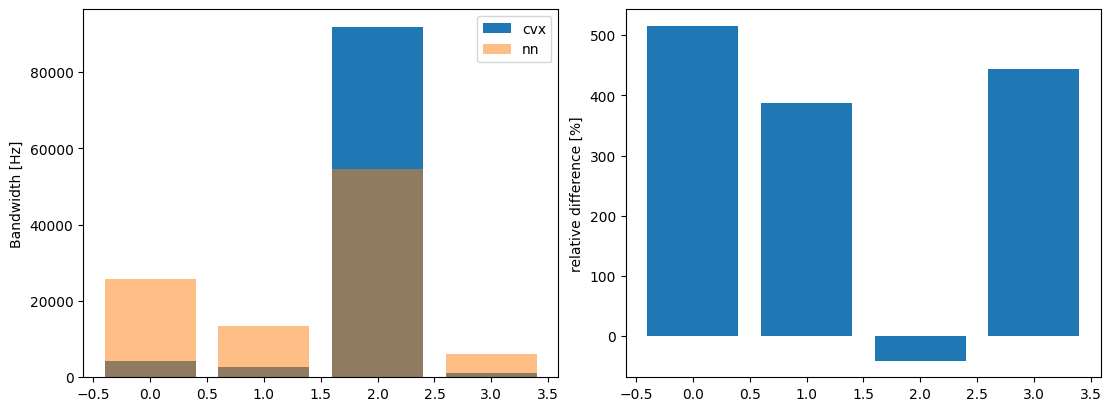

In [19]:


scenario_idx = len(beta) - 1
sample_idx = 16

    
plot_b_allocation_comparison(prob_beta_cvx, prob_beta[0], scenario_idx, sample_idx)

varied p_k

In [13]:
prob_p_k = [[], [], []]

for i in range(len(tr_power)):
    print(f'i = {i}')
    p_k = np.ones((test_length, K)) * tr_power[i]
    prob_p_k[0].append(Problem(D, H, tr_power=p_k))
    prob_p_k[0][-1].optimize(model=prob_p_k[0][-1].train_new_model(print_losses=False))
    prob_p_k[1].append(Problem(D, H, tr_power=p_k))
    prob_p_k[1][-1].optimize(model='uniform')
    prob_p_k[2].append(Problem(D, H, tr_power=p_k))
    prob_p_k[2][-1].optimize(model=prob_p_k[2][-1].train_new_model(print_losses=False, uniform_f_dt=True))

prob_p_k_cvx = get_cached_cvx_problems(
    'transmit_power',
    tr_power,
    lambda p_value: Problem(D, H, tr_power=np.ones((test_length, K)) * p_value),
)
t_total_p_k_nn = np.array([p.get_t_total_max() for p in prob_p_k[0]])
t_total_p_k_uniform_b = np.array([p.get_t_total_max() for p in prob_p_k[1]])
t_total_p_k_nn_uniform_f_dt = np.array([p.get_t_total_max() for p in prob_p_k[2]])
t_total_p_k_cvx = np.array([p.get_t_total_max() for p in prob_p_k_cvx])


i = 0
start training
best epoch: 06, best avg loss: 801.349915


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:191: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:191: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


start training
best epoch: 06, best avg loss: 804.468018


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:191: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


i = 1
start training
best epoch: 26, best avg loss: 390.911499


...

c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:431: RuntimeWarning: divide by zero encountered in divide
  1 / (mu) - beta,
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in add
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


best epoch: 87, best avg loss: 291.463013


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:431: RuntimeWarning: divide by zero encountered in divide
  1 / (mu) - beta,
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in add
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:431: RuntimeWarning:

start training
best epoch: 75, best avg loss: 294.095764
loaded cached CVX problems: transmit_power


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:431: RuntimeWarning: divide by zero encountered in divide
  1 / (mu) - beta,
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in add
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


C:\Users\YCMic\AppData\Local\Temp\ipykernel_12440\1814863797.py:237: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax_diff.set_ylim(*diff_ylim)


saved TikZ plot to plots\nn_vs_cvx_transmit_power.tex


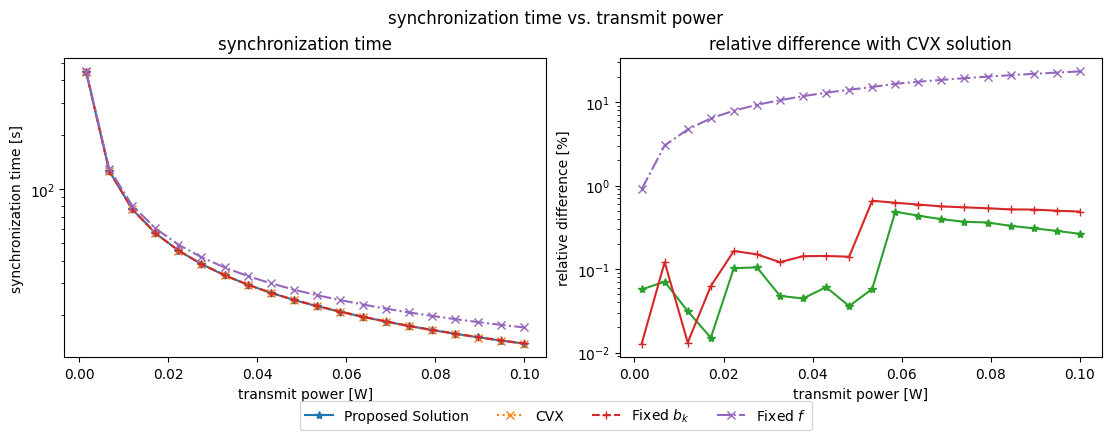

In [21]:
fig, axes, relative_diff_pct = plot_time_and_relative_diff(
    tr_power,
    t_total_p_k_nn,
    t_total_p_k_cvx,
    xlabel='transmit power [W]',
    title='synchronization time vs. transmit power',
    t_total_uniform=t_total_p_k_uniform_b,
    t_total_nn_uniform_f_dt=t_total_p_k_nn_uniform_f_dt,
    time_scale='semilogy',
    diff_scale='semilogy',
    tikz_path='plots/nn_vs_cvx_transmit_power.tex',
)

CVX:


|   sensor_num |        D |   H(dB) |         b |         f |   beta |   comp_speed |   tr_power |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|---------:|--------:|----------:|----------:|-------:|-------------:|-----------:|--------------:|-------------:|-----------:|-----------:|
|            0 | 3.82e+03 |  -39.43 | 6.330e+03 | 2.934e+06 |   1.23 |     2.00e+05 |   2.75e-02 |         20.01 |         0.80 |       6.18 |      13.03 |
|            1 | 2.20e+03 |  -41.11 | 3.777e+03 | 1.807e+06 |   1.39 |     2.00e+05 |   2.75e-02 |         20.00 |         1.04 |       6.80 |      12.16 |
|            2 | 4.28e+03 |  -41.41 | 2.732e+04 | 1.392e+07 |   1.41 |     2.00e+05 |   2.75e-02 |         20.02 |         2.27 |      14.68 |       3.07 |
|            3 | 5.70e+03 |  -40.87 | 6.248e+04 | 3.133e+07 |   1.36 |     2.00e+05 |   2.75e-02 |         20.02 |         2.38 |      15.82 |       1.82 |

NN:


|   sensor_num |        D |   H(dB) |         b |         f |   beta |   comp_speed |   tr_power |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|---------:|--------:|----------:|----------:|-------:|-------------:|-----------:|--------------:|-------------:|-----------:|-----------:|
|            0 | 3.82e+03 |  -39.43 | 2.183e+04 | 2.904e+06 |   1.23 |     2.00e+05 |   2.75e-02 |         20.02 |         0.78 |       6.08 |      13.16 |
|            1 | 2.20e+03 |  -41.11 | 1.069e+04 | 1.791e+06 |   1.38 |     2.00e+05 |   2.75e-02 |         20.02 |         1.03 |       6.72 |      12.28 |
|            2 | 4.28e+03 |  -41.41 | 2.643e+04 | 1.389e+07 |   1.41 |     2.00e+05 |   2.75e-02 |         20.02 |         2.27 |      14.68 |       3.08 |
|            3 | 5.70e+03 |  -40.87 | 4.105e+04 | 3.141e+07 |   1.36 |     2.00e+05 |   2.75e-02 |         20.02 |         2.38 |      15.83 |       1.81 |

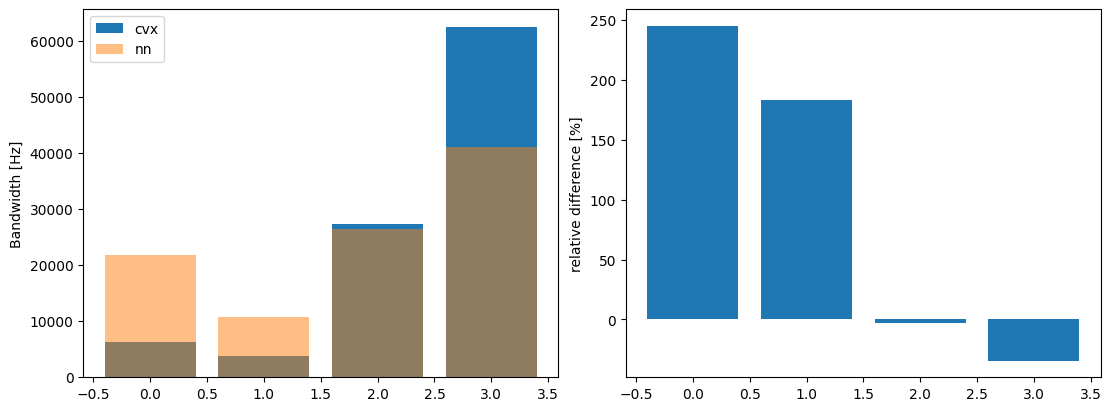

In [22]:


scenario_idx = 5
sample_idx = 10

    
plot_b_allocation_comparison(prob_p_k_cvx, prob_p_k[0], scenario_idx, sample_idx)

varied B

In [12]:
prob_B = [[], [], []]

for i in range(len(B_total)):
    print(f'i = {i}')
    prob_B[0].append(Problem(D, H, total_bandwidth=B_total[i]))
    prob_B[0][-1].optimize(model=prob_B[0][-1].train_new_model(print_losses=False))
    prob_B[1].append(Problem(D, H, total_bandwidth=B_total[i]))
    prob_B[1][-1].optimize(model='uniform')
    prob_B[2].append(Problem(D, H, total_bandwidth=B_total[i]))
    prob_B[2][-1].optimize(model=prob_B[2][-1].train_new_model(print_losses=False, uniform_f_dt=True))

prob_B_cvx = get_cached_cvx_problems(
    'bandwidth',
    B_total,
    lambda bandwidth: Problem(D, H, total_bandwidth=bandwidth),
)
t_total_B_nn = np.array([p.get_t_total_max() for p in prob_B[0]])
t_total_B_uniform_b = np.array([p.get_t_total_max() for p in prob_B[1]])
t_total_B_nn_uniform_f_dt = np.array([p.get_t_total_max() for p in prob_B[2]])
t_total_B_cvx = np.array([p.get_t_total_max() for p in prob_B_cvx])



i = 0
start training
best epoch: 01, best avg loss: 1.277259


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:191: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:191: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


start training
best epoch: 100, best avg loss: 2.042834
i = 1
start training


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:191: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


best epoch: 01, best avg loss: 1.277259


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:191: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:191: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:225: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:227: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


start training


KeyboardInterrupt: 

In [17]:
fig, axes, relative_diff_pct = plot_time_and_relative_diff(
    B_total,
    t_total_B_nn,
    t_total_B_cvx,
    xlabel='bandwidth $B$ [Hz]',
    title='synchronization time vs. total bandwidth',
    t_total_uniform=t_total_B_uniform_b,
    t_total_nn_uniform_f_dt=t_total_B_nn_uniform_f_dt,
    time_scale='semilogx',
    diff_scale='semilogx',
)

Error in callback <function _draw_all_if_interactive at 0x0000027D36F4F740> (for post_execute):


ValueError: 
\fdt
^
ParseFatalException: Unknown symbol: \fdt, found '\'  (at char 0), (line:1, col:1)

ValueError: 
\fdt
^
ParseFatalException: Unknown symbol: \fdt, found '\'  (at char 0), (line:1, col:1)

<Figure size 1100x400 with 2 Axes>

CVX:


|   sensor_num |        D |   H(dB) |         b |         f |   beta |   comp_speed |   tr_power |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|---------:|--------:|----------:|----------:|-------:|-------------:|-----------:|--------------:|-------------:|-----------:|-----------:|
|            0 | 1.82e+03 |  -38.56 | 1.458e+01 | 2.717e+06 |   1.61 |     2.00e+05 |   3.16e-02 |         23.17 |         2.23 |      14.26 |       6.68 |
|            1 | 4.62e+03 |  -40.87 | 1.314e+02 | 1.688e+07 |   1.44 |     2.00e+05 |   3.16e-02 |         23.18 |         2.75 |      17.69 |       2.74 |
|            2 | 6.14e+03 |  -40.26 | 1.935e+02 | 2.404e+07 |   1.37 |     2.00e+05 |   3.16e-02 |         23.18 |         2.71 |      17.91 |       2.56 |
|            3 | 3.42e+03 |  -38.96 | 3.983e+01 | 6.360e+06 |   1.47 |     2.00e+05 |   3.16e-02 |         23.18 |         2.41 |      15.38 |       5.38 |

NN:


|   sensor_num |        D |   H(dB) |         b |         f |   beta |   comp_speed |   tr_power |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|---------:|--------:|----------:|----------:|-------:|-------------:|-----------:|--------------:|-------------:|-----------:|-----------:|
|            0 | 1.82e+03 |  -38.56 | 3.105e+01 | 1.340e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         23.88 |         1.41 |       8.93 |      13.55 |
|            1 | 4.62e+03 |  -40.87 | 1.146e+02 | 1.825e+07 |   1.45 |     2.00e+05 |   3.16e-02 |         23.88 |         2.88 |      18.47 |       2.53 |
|            2 | 6.14e+03 |  -40.26 | 1.658e+02 | 2.715e+07 |   1.38 |     2.00e+05 |   3.16e-02 |         23.88 |         2.86 |      18.76 |       2.26 |
|            3 | 3.42e+03 |  -38.96 | 6.782e+01 | 3.260e+06 |   1.41 |     2.00e+05 |   3.16e-02 |         23.88 |         1.79 |      11.60 |      10.50 |

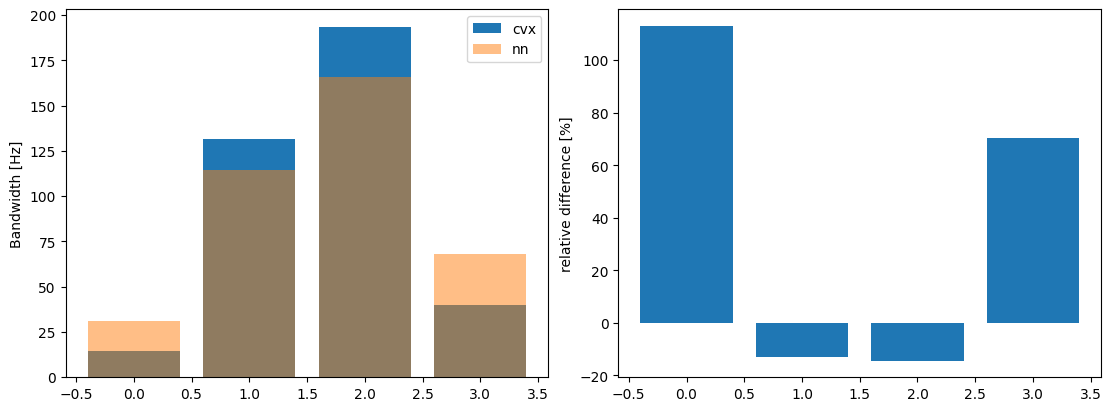

In [11]:

scenario_idx = 1
sample_idx = 6

    
plot_b_allocation_comparison(prob_B_cvx, prob_B[0], scenario_idx, sample_idx)

relative differences between NN and CVX for random scenarios

In [5]:
n_random_scenarios = 100
random_K = 4
samples_per_scenario = 1
rng = np.random.default_rng(42)
random_cvx_cache_key = f'{cvx_cache_version}_random_relative_diff_K_{random_K}_N_{n_random_scenarios}_samples_{samples_per_scenario}_seed_42'

if random_cvx_cache_key in cvx_cache:
    print('loaded cached CVX problems: random relative diff')
    prob_random_cvx = [_problem_from_cache_entry(entry) for entry in cvx_cache[random_cvx_cache_key]]
else:
    print('running CVX problems: random relative diff')
    set_seed(42)
    prob_random_cvx = []
    for i in range(n_random_scenarios):
        total_data_bits = random_K * 4e3
        D_random = (DataUtil.generate_D_k_distribution(samples_per_scenario, random_K) * total_data_bits).numpy()
        H_random = DataUtil.generate_channel_gains(samples_per_scenario, random_K).numpy()

        beta_max_random = rng.uniform(1.0, 2.5)
        tr_power_random = rng.uniform(1.6e-3, 100e-3)
        bandwidth_random = 10 ** rng.uniform(2, 5)
        p_random = np.ones((samples_per_scenario, random_K)) * tr_power_random

        print(f'cvx random scenario {i}: beta={beta_max_random:.3f}, p={tr_power_random:.4g}, B={bandwidth_random:.4g}')

        prob_cvx = Problem(
            D_random,
            H_random,
            tr_power=p_random,
            beta_max=beta_max_random,
            total_bandwidth=bandwidth_random,
        )
        prob_cvx.optimize(model='cvx')
        prob_random_cvx.append(prob_cvx)

    cvx_cache[random_cvx_cache_key] = [_problem_to_cache_entry(problem) for problem in prob_random_cvx]
    with open(cvx_cache_path, 'wb') as f:
        pickle.dump(cvx_cache, f)

relative_diff_rows = []

for i, prob_cvx in enumerate(prob_random_cvx):
    D_random = prob_cvx.D
    H_random = prob_cvx.H_mag
    p_random = prob_cvx.tr_power
    beta_max_random = prob_cvx.beta_max
    tr_power_random = float(np.mean(prob_cvx.tr_power))
    bandwidth_random = prob_cvx.total_bandwidth

    print(f'scenario {i}: beta={beta_max_random:.3f}, p={tr_power_random:.4g}, B={bandwidth_random:.4g}')

    prob_nn = Problem(
        D_random,
        H_random,
        tr_power=p_random,
        beta_max=beta_max_random,
        total_bandwidth=bandwidth_random,
    )
    prob_nn.optimize(model=prob_nn.train_new_model(print_losses=False))
    t_nn = prob_nn.get_t_total_max()

    t_cvx = prob_cvx.get_t_total_max()

    relative_diff_pct = 100 * (t_nn - t_cvx) / t_cvx

    relative_diff_rows.append(
        {
            'scenario': i,
            'K': random_K,
            'beta_max': beta_max_random,
            'transmit_power_W': tr_power_random,
            'bandwidth_Hz': bandwidth_random,
            't_total_NN_s': t_nn,
            't_total_CVX_s': t_cvx,
            'relative_diff_pct': relative_diff_pct,
            'abs_relative_diff_pct': abs(relative_diff_pct),
        }
    )

relative_diff_df = pd.DataFrame(relative_diff_rows)
display(relative_diff_df)

print(f"mean relative diff: {relative_diff_df['relative_diff_pct'].mean():.2f}%")
print(f"mean absolute relative diff: {relative_diff_df['abs_relative_diff_pct'].mean():.2f}%")




loaded cached CVX problems: random relative diff
scenario 0: beta=2.161, p=0.04479, B=3.765e+04
start training
best epoch: 74, best avg loss: 56.222511
scenario 1: beta=2.046, p=0.01087, B=8.45e+04
start training
best epoch: 46, best avg loss: 153.925735
scenario 2: beta=2.142, p=0.07895, B=242.3
start training
best epoch: 100, best avg loss: 54.151737
scenario 3: beta=1.676, p=0.03809, B=6.03e+04
start training


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:186: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:220: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:222: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


best epoch: 34, best avg loss: 50.653301
scenario 4: beta=1.966, p=0.08256, B=2139
start training


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:186: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:220: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:222: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


best epoch: 99, best avg loss: 34.385693
scenario 5: beta=1.341, p=0.05617, B=155.4
start training


...

best epoch: 100, best avg loss: 80.479828
scenario 85: beta=2.119, p=0.08195, B=206.9
start training
best epoch: 100, best avg loss: 53.927227
scenario 86: beta=1.100, p=0.06009, B=274.5
start training
best epoch: 99, best avg loss: 56.184212
scenario 87: beta=2.237, p=0.03214, B=270.2
start training
best epoch: 99, best avg loss: 85.967606
scenario 88: beta=2.381, p=0.01789, B=714.8
start training
best epoch: 99, best avg loss: 125.673668
scenario 89: beta=1.230, p=0.01296, B=115.7
start training
best epoch: 97, best avg loss: 202.437546
scenario 90: beta=1.083, p=0.01878, B=144.6
start training


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:186: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:220: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:222: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


best epoch: 100, best avg loss: 153.704865
scenario 91: beta=1.887, p=0.06858, B=1517
start training
best epoch: 99, best avg loss: 36.615433
scenario 92: beta=1.477, p=0.05125, B=4.217e+04
start training
best epoch: 56, best avg loss: 39.691360
scenario 93: beta=2.277, p=0.005878, B=350.3
start training
best epoch: 100, best avg loss: 283.120850
scenario 94: beta=1.355, p=0.02614, B=5172
start training
best epoch: 100, best avg loss: 77.099487
scenario 95: beta=1.624, p=0.006447, B=1321
start training
best epoch: 84, best avg loss: 277.506378
scenario 96: beta=1.786, p=0.0116, B=3.165e+04
start training
best epoch: 28, best avg loss: 149.009842
scenario 97: beta=1.078, p=0.0926, B=198.3
start training
best epoch: 99, best avg loss: 48.792530
scenario 98: beta=2.265, p=0.09042, B=8.684e+04
start training
best epoch: 87, best avg loss: 50.647812
scenario 99: beta=2.203, p=0.0783, B=8462
start training
best epoch: 89, best avg loss: 47.230488


,scenario,K,beta_max,transmit_power_W,bandwidth_Hz,t_total_NN_s,t_total_CVX_s,relative_diff_pct,abs_relative_diff_pct
0,0,4,2.160934,0.044786,37652.495018,20.587986,20.542231,0.222738,0.222738
1,1,4,2.046052,0.010867,84502.013021,65.969948,65.960266,0.014678,0.014678
2,2,4,2.141710,0.078949,242.293017,26.147924,25.680519,1.820077,1.820077
3,3,4,1.675579,0.038087,60296.897486,17.084454,17.083931,0.003059,0.003059
4,4,4,1.965798,0.082560,2139.156687,14.003924,13.654860,2.556334,2.556334
...,...,...,...,...,...,...,...,...,...
95,95,4,1.624394,0.006447,1320.816286,188.014816,187.444031,0.304510,0.304510
96,96,4,1.785629,0.011605,31650.141892,87.399582,87.399826,-0.000279,0.000279
97,97,4,1.077943,0.092604,198.307630,22.331894,21.984358,1.580833,1.580833
98,98,4,2.265362,0.090421,86838.445748,9.541388,9.529179,0.128122,0.128122


mean relative diff: 3.00%
mean absolute relative diff: 3.00%


saved TikZ plot to plots\nn_vs_cvx_random_scenarios.tex


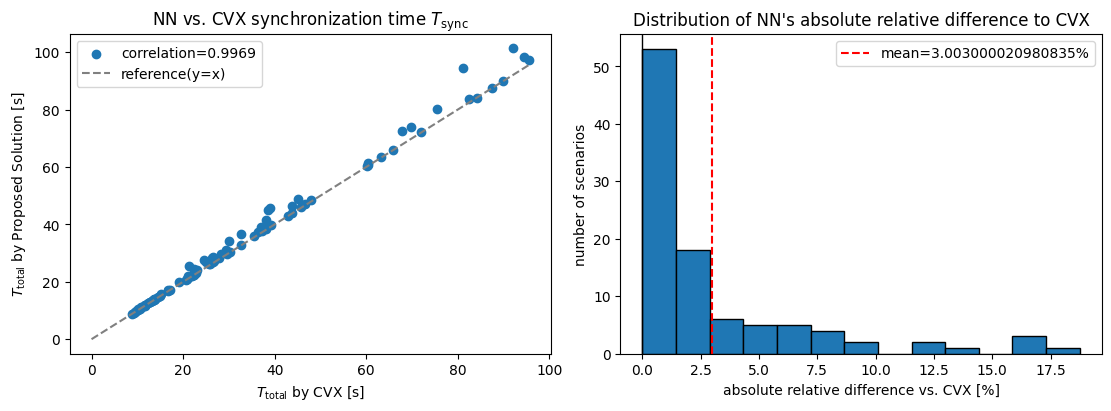

In [ ]:
fig, (ax_scatter, ax_distribution) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

t_total_CVX = relative_diff_df['t_total_CVX_s']
t_total_NN = relative_diff_df['t_total_NN_s']

ax_scatter.scatter(t_total_CVX, t_total_NN, label=f'correlation={np.corrcoef(t_total_CVX, t_total_NN)[0,1].round(4)}')
ax_scatter.plot(np.linspace(0, t_total_CVX.max()), np.linspace(0, t_total_CVX.max()), color='grey', linestyle='--', label='reference(y=x)')
ax_scatter.set_title(r'NN vs. CVX synchronization time $T_{\mathrm{sync}}$')
ax_scatter.set_xlabel(r'$T_{\mathrm{total}}$ by CVX [s]')
ax_scatter.set_ylabel(r'$T_{\mathrm{total}}$ by Proposed Solution [s]')
ax_scatter.legend()

ax_distribution.hist(relative_diff_df['abs_relative_diff_pct'], bins='auto', edgecolor='black')
ax_distribution.axvline(0, color='black', linewidth=1)
ax_distribution.axvline(relative_diff_df['relative_diff_pct'].mean(), color='red', linestyle='--', label=f'mean={round(relative_diff_df['relative_diff_pct'].mean(), 4)}%')
ax_distribution.set_xlabel('absolute relative difference vs. CVX [%]')
ax_distribution.set_ylabel('number of scenarios')
ax_distribution.set_title('Distribution of NN\'s absolute relative difference to CVX')
ax_distribution.legend()


def export_random_relative_diff_tikz(path, results):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    cvx_times = results['t_total_CVX_s'].to_numpy(dtype=float)
    nn_times = results['t_total_NN_s'].to_numpy(dtype=float)
    abs_differences = results['abs_relative_diff_pct'].to_numpy(dtype=float)
    correlation = np.corrcoef(cvx_times, nn_times)[0, 1]
    mean_abs_difference = abs_differences.mean()
    reference_max = max(cvx_times.max(), nn_times.max())
    bin_width = 2.0
    bin_upper = bin_width * np.ceil(abs_differences.max() / bin_width)
    bin_edges = np.arange(0, bin_upper + 0.5 * bin_width, bin_width)
    counts, bin_edges = np.histogram(abs_differences, bins=bin_edges)

    def coordinates(x, y):
        return ' '.join(f'({x_i:.12g},{y_i:.12g})' for x_i, y_i in zip(x, y))

    histogram_data = ('\\\\' + '\n').join(f'{value:.12g}' for value in abs_differences)
    tikz = f'''\\begin{{tikzpicture}}
\\begin{{groupplot}}[
    group style={{group size=2 by 1, horizontal sep=1.5cm}},
    width=0.48\\linewidth,
    grid=both,
]
\\nextgroupplot[
    xlabel={{$\\tsyncavg$ by CVX [s]}},
    ylabel={{$\\tsyncavg$ by Proposed Solution [s]}},
    title={{NN vs. CVX synchronization time}},
]
\\addplot[only marks, blue, mark=*, mark size=1.5pt] coordinates {{{coordinates(cvx_times, nn_times)}}};
\\addlegendentry{{correlation={correlation:.4f}}}
\\addplot[grey, dashed, domain=0:{reference_max:.12g}] {{x}};
\\addlegendentry{{reference ($y=x$)}}
\\nextgroupplot[
    xlabel={{absolute relative difference vs. CVX [\\%]}},
    ylabel={{number of scenarios}},
    title={{Distribution of absolute relative differences}},
    xmin=0, xmax={bin_upper:.12g},
    xtick distance={bin_width:.12g},
]
\\addplot+[hist={{bins={len(counts)}, data min=0, data max={bin_upper:.12g}}}, fill=blue!35, draw=black] table[row sep=\\\\, y index=0] {{
data\\\\
{histogram_data}\\\\
}};
\\addplot[red, dashed, thick] coordinates {{({mean_abs_difference:.12g},0) ({mean_abs_difference:.12g},{counts.max():.12g})}};
\\addlegendentry{{mean={mean_abs_difference:.4f}\\%}}
\\end{{groupplot}}
\\end{{tikzpicture}}
'''
    path.write_text(tikz, encoding='utf-8')
    print(f'saved TikZ plot to {path}')


export_random_relative_diff_tikz(
    'plots/nn_vs_cvx_random_scenarios.tex',
    relative_diff_df,
)


covariance between scenario parameters and relative difference

In [61]:
corr_df_input = relative_diff_df.copy()
corr_df_input['log10_bandwidth_Hz'] = np.log10(corr_df_input['bandwidth_Hz'])

correlation_columns = [
    'beta_max',
    'transmit_power_W',
    'log10_bandwidth_Hz',
    'relative_diff_pct',
]

corr_df = corr_df_input[correlation_columns].corr()
corr_to_diff = corr_df[['relative_diff_pct']].drop(index='relative_diff_pct')

display(corr_to_diff.rename(columns={'relative_diff_pct': 'correlation_with_relative_diff_pct'}))

,correlation_with_relative_diff_pct
beta_max,-0.080801
transmit_power_W,-0.015910
log10_bandwidth_Hz,-0.672910


Runtime

In [5]:
import torch
from NNSolver import Net

runtime_K_values = range(4, 101, 10)
runtime_n_scenarios = 100
runtime_n_epoch = 100
runtime_train_length = int(1e4)
runtime_max_iters = 30
runtime_follower_iters = 20
runtime_tol = 1e-6
runtime_seed = 42

runtime_data_path = Path('data/runtime_D_H.pkl')
runtime_result_path = Path('data/runtime_results.pkl')
runtime_model_dir = Path('models')
runtime_figure_path = Path('data/runtime_plots.png')


In [6]:
def generate_or_load_runtime_data():
    if runtime_data_path.exists():
        with runtime_data_path.open('rb') as f:
            runtime_data = pickle.load(f)
            return runtime_data

    torch.manual_seed(runtime_seed)
    runtime_data = {}

    for K in runtime_K_values:
        D = DataUtil.generate_D_k_distribution(runtime_n_scenarios, K) * (K * c.D_avg)
        H = DataUtil.generate_channel_gains(runtime_n_scenarios, K)
        runtime_data[K] = {'D': D.numpy(), 'H': H.numpy()}

    runtime_data_path.parent.mkdir(exist_ok=True)
    with runtime_data_path.open('wb') as f:
        pickle.dump(runtime_data, f)

    return runtime_data


def load_or_train_runtime_model(K, D, H):
    runtime_model_dir.mkdir(exist_ok=True)
    model_path = runtime_model_dir / f'runtime_model_K_{K}.pt'
    prob = Problem(D, H)

    model = Net(K, prob.total_bandwidth, c.total_compute_power, prob.beta_max).to(prob.device)

    if model_path.exists():
        model.load_state_dict(torch.load(model_path, map_location=prob.device))
        model.eval()
        return model

    model = prob.train_new_model(
        print_losses=False,
        n_epoch=runtime_n_epoch,
        train_length=runtime_train_length,
    )
    torch.save(model.state_dict(), model_path)
    model.eval()
    return model


def run_runtime_case(K, D, H):
    model = load_or_train_runtime_model(K, D, H)

    prob_nn = Problem(D, H)
    prob_nn.optimize(
        model=model,
        max_iters=runtime_max_iters,
        tol=runtime_tol,
        follower_iters=runtime_follower_iters,
    )

    prob_cvx = Problem(D, H)
    prob_cvx.optimize(
        model='cvx',
        max_iters=runtime_max_iters,
        tol=runtime_tol,
        follower_iters=runtime_follower_iters,
    )
    
    comparison_mask = prob_cvx.get_cvx_success_mask()

    return {
        'K': K,
        'runtime_NN_s': prob_nn.get_total_time_used(),
        'runtime_CVX_s': prob_cvx.get_total_time_used(),
        'solver_time_NN_s': float(np.mean(prob_nn.get_leader_time_used())),
        'solver_time_CVX_s': float(np.mean(prob_cvx.get_leader_time_used())),
        't_total_NN_s': prob_nn.get_t_total_max(comparison_mask),
        't_total_CVX_s': prob_cvx.get_t_total_max(comparison_mask),
        'n_compared': int(comparison_mask.sum()) if comparison_mask is not None else len(D),
        'n_cvx_failed': int((~comparison_mask).sum()) if comparison_mask is not None else 0,
    }


def run_runtime_benchmark():
    runtime_data = generate_or_load_runtime_data()

    if runtime_result_path.exists():
        with runtime_result_path.open('rb') as f:
            runtime_results = pickle.load(f)
    else:
        runtime_results = []

    completed_K = {row['K'] for row in runtime_results}

    for K in runtime_K_values:
        if K in completed_K:
            # if K == 54:
            #     print('Rerunning K=54 with failed CVX scenarios excluded')
            #     runtime_results = [row for row in runtime_results if row['K'] != K]
            #     runtime_results.append(run_runtime_case(K, runtime_data[K]['D'], runtime_data[K]['H']))
            #     runtime_results.sort(key=lambda row: row['K'])
                # with runtime_result_path.open('wb') as f:
                #     pickle.dump(runtime_results, f)
                # continue
            print(f'Skipping K={K}; already cached')
            continue
        
        
            

        print(f'Running K={K}')
        runtime_results.append(run_runtime_case(K, runtime_data[K]['D'], runtime_data[K]['H']))

        runtime_result_path.parent.mkdir(exist_ok=True)
        with runtime_result_path.open('wb') as f:
            pickle.dump(runtime_results, f)

    return pd.DataFrame(runtime_results).sort_values('K').reset_index(drop=True)


In [7]:
runtime_df = run_runtime_benchmark()

runtime_df


Skipping K=4; already cached
Skipping K=14; already cached
Skipping K=24; already cached
Skipping K=34; already cached
Skipping K=44; already cached
Skipping K=54; already cached
Skipping K=64; already cached
Skipping K=74; already cached
Skipping K=84; already cached
Skipping K=94; already cached


,K,runtime_NN_s,runtime_CVX_s,solver_time_NN_s,solver_time_CVX_s,t_total_NN_s,t_total_CVX_s,n_compared,n_cvx_failed
0,4,0.202777,29.445289,0.000031,0.000907,34.138847,34.129330,NaN,NaN
1,14,0.300544,81.928433,0.000034,0.002181,83.423454,83.385818,NaN,NaN
2,24,0.319966,123.124185,0.000035,0.003250,79.830116,79.268555,NaN,NaN
3,34,0.288013,174.448297,0.000031,0.004621,84.118965,83.802971,NaN,NaN
4,44,0.359106,222.315428,0.000035,0.005951,103.710426,101.908974,NaN,NaN
5,54,0.384821,284.955727,0.000037,0.009438,102.246178,113.151756,96.0,4.0
6,64,0.431527,324.850354,0.000036,0.009382,124.794342,124.226570,NaN,NaN
7,74,0.464948,371.999785,0.000036,0.010490,153.879272,153.242447,NaN,NaN
8,84,0.500096,420.128516,0.000031,0.011396,147.489349,144.284607,NaN,NaN
9,94,0.572986,473.090567,0.000038,0.013793,194.350723,194.026581,NaN,NaN


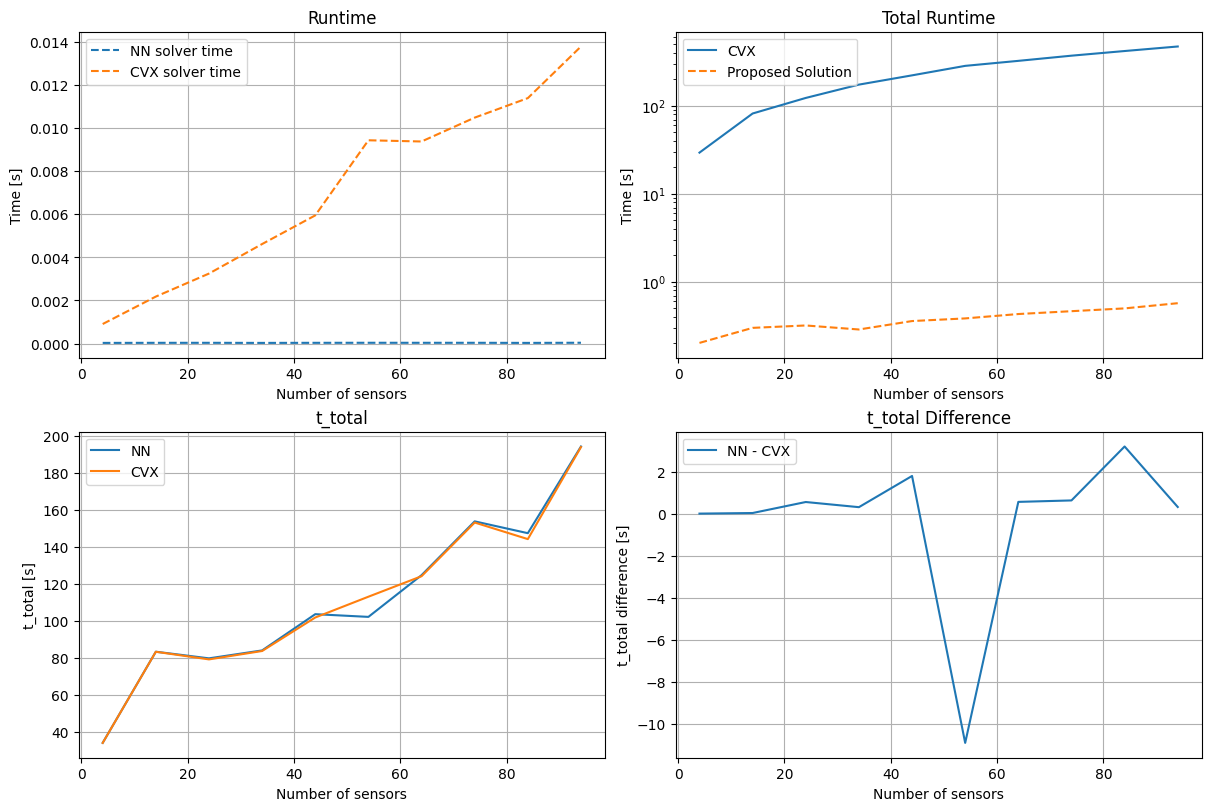

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

K = runtime_df['K']

ax = axes[0, 0]
# ax.semilogy(K, runtime_df['runtime_NN_s'], label='NN total runtime')
# ax.semilogy(K, runtime_df['runtime_CVX_s'], label='CVX total runtime')
ax.plot(K, runtime_df['solver_time_NN_s'], '--', label='NN solver time')
ax.plot(K, runtime_df['solver_time_CVX_s'], '--', label='CVX solver time')
ax.set_title('Runtime')
ax.set_xlabel('Number of sensors')
ax.set_ylabel('Time [s]')
ax.legend()
ax.grid(True)

ax = axes[0, 1]
ax.semilogy(K, runtime_df['runtime_CVX_s'], label='CVX')
ax.semilogy(K, runtime_df['runtime_NN_s'], linestyle='--', label='Proposed Solution')
ax.set_title('Total Runtime')
ax.set_xlabel('Number of sensors')
ax.set_ylabel('Time [s]')
ax.legend()
ax.grid(True)

ax = axes[1, 0]
ax.plot(K, runtime_df['t_total_NN_s'], label='NN')
ax.plot(K, runtime_df['t_total_CVX_s'], label='CVX')
ax.set_title('t_total')
ax.set_xlabel('Number of sensors')
ax.set_ylabel('t_total [s]')
ax.legend()
ax.grid(True)

ax = axes[1, 1]
ax.plot(K, runtime_df['t_total_NN_s'] - runtime_df['t_total_CVX_s'], label='NN - CVX')
ax.set_title('t_total Difference')
ax.set_xlabel('Number of sensors')
ax.set_ylabel('t_total difference [s]')
ax.legend()
ax.grid(True)

runtime_figure_path.parent.mkdir(exist_ok=True)
fig.savefig(runtime_figure_path, dpi=200)
plt.show()


## Training loss over epochs

In [5]:
from torch.optim import AdamW, lr_scheduler
from DataUtil import generate_data_loader
from EarlyStopping import EarlyStopping
from TrainingUtil import (
    current_lr,
    relative_to_uniform_loss,
    step_scheduler,
    test_loop,
    train_loop,
)
from NNSolver import Net

# Match the default configuration in Problem.train_new_model.
loss_n_epoch = 100
loss_train_length = int(1e4)
loss_problem = Problem(D, H)

set_seed()
loss_model = Net(
    loss_problem.K,
    loss_problem.total_bandwidth,
    c.total_compute_power,
    loss_problem.beta_max,
).to(loss_problem.device)

loss_train_loader, loss_test_loader = generate_data_loader(
    loss_train_length,
    loss_problem.K,
    loss_problem.K * 4e3,
    comp_speed_range=[
        c.sensor_compression_speed / 2,
        c.sensor_compression_speed * 2,
    ],
    tr_power_range=[
        loss_problem.tr_power.mean() / 2,
        loss_problem.tr_power.mean() * 2,
    ],
    beta_max=loss_problem.beta_max,
)

loss_optimizer = AdamW(loss_model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_scheduler = lr_scheduler.LinearLR(optimizer=loss_optimizer)
loss_early_stopper = EarlyStopping(patience=10, min_delta=1e-5, relative=True)
train_loss_history = []
test_loss_history = []

print('start training')
for epoch in range(loss_n_epoch):
    train_loss = train_loop(
        loss_model,
        loss_train_loader,
        loss_optimizer,
        relative_to_uniform_loss,
        loss_problem.device,
    )
    test_loss = test_loop(
        loss_model,
        loss_test_loader,
        relative_to_uniform_loss,
        loss_problem.device,
    )
    train_loss_history.append(train_loss)
    test_loss_history.append(test_loss)

    print(
        f'epoch: {epoch + 1:02d}, '
        f'train loss: {train_loss:.6f}, '
        f'test loss: {test_loss:.6f}, '
        f'lr: {current_lr(loss_optimizer):.2e}'
    )

    step_scheduler(loss_scheduler, train_loss)
    should_stop, best_epoch = loss_early_stopper(epoch, test_loss, loss_model)
    if should_stop:
        break

loss_early_stopper.restore_best_model(loss_model)
loss_model.eval()

epochs = np.arange(1, len(train_loss_history) + 1)
best_epoch_number = loss_early_stopper.best_epoch + 1

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.plot(epochs, train_loss_history, label='Training loss')
ax.plot(epochs, test_loss_history, label='Test loss')
ax.axvline(
    best_epoch_number,
    color='tab:green',
    linestyle='--',
    label=f'Best epoch ({best_epoch_number})',
)
ax.set_xlabel('Epoch')
ax.axhline(1.0, color='tab:gray', linestyle=':', label='Uniform baseline')
ax.set_ylabel('Completion time / uniform completion time')
ax.set_title('Relative training and test loss over epochs')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


ImportError: cannot import name 'current_lr' from 'TrainingUtil' (c:\Users\YCMic\Documents\Bachelor-Thesis\src\TrainingUtil.py)